# Exemplo prático de sistema de ODE rígido: Lorenz

Neste notebook, vamos explorar o que acontece com um sistema de equações diferenciais ordinárias rígidas. Para isso, vamos considerar um modelo clássico com essas características: o sistema de Lorenz.

O objetivo principal é observar três fenômenos numéricos que aparecem juntos em muitos sistemas dinâmicos não lineares:

* restrições de estabilidade para métodos explícitos;
* dissipação artificial introduzida por métodos implícitos de baixa ordem;
* perda de concordância ponto a ponto em tempos longos devido à sensibilidade a perturbações.

Uma observação importante: **rigidez e caos não são a mesma coisa**. Rigidez está ligada à presença de escalas temporais muito diferentes e a restrições severas de estabilidade para métodos explícitos. Caos está ligado à sensibilidade a pequenas perturbações. O sistema de Lorenz é um bom laboratório porque permite visualizar esses dois tipos de dificuldade numérica.

## Importando as dependências

Usaremos `numpy`, `pandas`, `matplotlib` e os integradores adaptativos de `scipy.integrate.solve_ivp`.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp

plt.rcParams.update(
    {
        "axes.grid": True,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.figsize": (8, 4.5),
        "font.size": 11,
    }
)

## Rigidez, estabilidade e tempo longo

Em um problema de valor inicial,

$$
\mathbf{y}'(t)=\mathbf{f}(t,\mathbf{y}),
\qquad
\mathbf{y}(0)=\mathbf{y}_0,
$$

dizemos, de forma prática, que o problema é rígido quando métodos explícitos precisam usar passos muito pequenos por estabilidade, mesmo quando a solução parece variar em uma escala mais lenta.

Para uma equação linear escalar $y'=\lambda y$, o Euler explícito produz

$$
y_{n+1}=(1+h\lambda)y_n.
$$

Se $\lambda$ tem parte real negativa e grande em módulo, a solução contínua decai rapidamente. No entanto, o método explícito só é estável se $|1+h\lambda|$ estiver dentro da região de estabilidade. Assim, um modo que deveria simplesmente decair pode explodir numericamente quando $h$ é grande demais.

Em sistemas não lineares, olhamos localmente para o Jacobiano $J(\mathbf{y})=\partial \mathbf{f}/\partial \mathbf{y}$. Autovalores com partes reais negativas grandes indicam direções rapidamente dissipativas, que costumam impor restrições de estabilidade a métodos explícitos.

Para sistemas caóticos, há ainda outro ponto: mesmo quando dois métodos estão ambos resolvendo bem o problema em tempos curtos, pequenas diferenças numéricas crescem com o tempo. Portanto, em tempos longos, não esperamos que as trajetórias coincidam ponto a ponto; esperamos que preservem características qualitativas do atrator.

## O sistema de Lorenz

O sistema de Lorenz clássico é dado por

$$
\begin{aligned}
x'(t) &= \sigma(y-x),\\
y'(t) &= x(\rho-z)-y,\\
z'(t) &= xy-\beta z.
\end{aligned}
$$

Vamos usar os parâmetros clássicos

$$
\sigma=10,\qquad \rho=28,\qquad \beta=\frac{8}{3},
$$

e a condição inicial

$$
(x_0,y_0,z_0)=(1,1,1).
$$

Nessa configuração, o sistema apresenta o atrator de Lorenz, com forte sensibilidade a pequenas perturbações.

In [2]:
lorenz_params = (10.0, 28.0, 8.0 / 3.0)
sigma_lorenz, rho_lorenz, beta_lorenz = lorenz_params
z0_lorenz = np.array([1.0, 1.0, 1.0])


def lorenz_rhs(t, state, sigma, rho, beta):
    x, y, z = state
    return np.array(
        [
            sigma * (y - x),
            x * (rho - z) - y,
            x * y - beta * z,
        ],
        dtype=float,
    )


def lorenz_jacobian(state, sigma, rho, beta):
    x, y, z = state
    return np.array(
        [
            [-sigma, sigma, 0.0],
            [rho - z, -1.0, -x],
            [y, x, -beta],
        ],
        dtype=float,
    )


pd.DataFrame(
    {
        "parâmetro": ["sigma", "rho", "beta", "x0", "y0", "z0"],
        "valor": [sigma_lorenz, rho_lorenz, beta_lorenz, *z0_lorenz],
    }
)

,parâmetro,valor
0,sigma,10.000000
1,rho,28.000000
2,beta,2.666667
3,x0,1.000000
4,y0,1.000000
5,z0,1.000000


O Jacobiano será usado de duas maneiras: para implementar o Euler implícito por Newton e para interpretar localmente a presença de direções com escalas temporais diferentes.

In [3]:
initial_jacobian_eigenvalues = np.linalg.eigvals(
    lorenz_jacobian(z0_lorenz, *lorenz_params)
)

pd.DataFrame(
    {
        "autovalor de J(y0)": [
            f"{eig.real:+.4f}{eig.imag:+.4f}i" for eig in initial_jacobian_eigenvalues
        ]
    }
)

,autovalor de J(y0)
0,-22.5330+0.0000i
1,+11.4713+0.0000i
2,-2.6050+0.0000i


Os autovalores acima são apenas uma informação local, calculada na condição inicial. Ao longo da trajetória, o Jacobiano muda continuamente. Ainda assim, eles já indicam que há direções com taxas de variação bastante diferentes, um sinal de que métodos explícitos podem enfrentar restrições de passo.

## Uma solução de referência com `solve_ivp`

Primeiro, vamos calcular uma solução de referência em um intervalo moderado. Como estamos interessados em discutir rigidez, vamos usar `Radau`, um método implícito adequado para problemas rígidos, com tolerâncias mais estritas do que as usadas na comparação posterior.

Essa referência não deve ser interpretada como “verdade absoluta” em tempos longos. Em um sistema caótico, uma solução numérica de alta precisão é útil para comparações iniciais, mas a concordância ponto a ponto inevitavelmente se perde após algum tempo.

In [4]:
T_lorenz = 35.0
t_eval_lorenz = np.linspace(0.0, T_lorenz, 3501)

sol_reference = sp.integrate.solve_ivp(
    lorenz_rhs,
    t_span=(0.0, T_lorenz),
    y0=z0_lorenz,
    args=lorenz_params,
    method="Radau",
    t_eval=t_eval_lorenz,
    dense_output=True,
    rtol=1e-8,
    atol=1e-10,
)

lorenz_reference = sol_reference.y.T
sol_reference.success, sol_reference.nfev

(True, 91237)

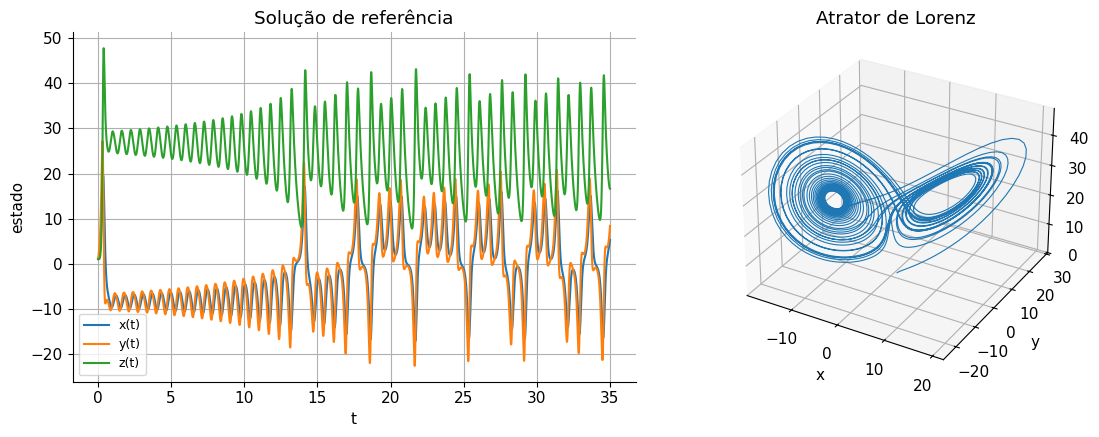

In [5]:
fig = plt.figure(figsize=(12, 4.5))
ax_time = fig.add_subplot(1, 2, 1)
ax_phase = fig.add_subplot(1, 2, 2, projection="3d")

ax_time.plot(sol_reference.t, lorenz_reference[:, 0], label="x(t)")
ax_time.plot(sol_reference.t, lorenz_reference[:, 1], label="y(t)")
ax_time.plot(sol_reference.t, lorenz_reference[:, 2], label="z(t)")
ax_time.set_xlabel("t")
ax_time.set_ylabel("estado")
ax_time.set_title("Solução de referência")
ax_time.legend(fontsize=9)

ax_phase.plot(
    lorenz_reference[:, 0],
    lorenz_reference[:, 1],
    lorenz_reference[:, 2],
    linewidth=0.8,
)
ax_phase.set_xlabel("x")
ax_phase.set_ylabel("y")
ax_phase.set_zlabel("z")
ax_phase.set_title("Atrator de Lorenz")

fig.tight_layout()
plt.show()

O atrator de Lorenz tem uma geometria característica, com duas “asas”. Em tempos longos, trajetórias próximas podem trocar de asa em instantes diferentes. Isso faz com que comparações ponto a ponto sejam muito sensíveis ao método, à tolerância e ao passo usados.

## Implementações manuais: Euler explícito e implícito

Agora vamos implementar dois métodos de primeira ordem com passo fixo.

O Euler explícito é

$$
\mathbf{z}_{n+1}=\mathbf{z}_n+h\mathbf{f}(t_n,\mathbf{z}_n).
$$

O Euler implícito é

$$
\mathbf{z}_{n+1}=\mathbf{z}_n+h\mathbf{f}(t_{n+1},\mathbf{z}_{n+1}).
$$

Para o sistema de Lorenz, o Euler implícito exige resolver um sistema não linear em cada passo. Faremos isso com Newton:

$$
\mathbf{F}(\mathbf{z}_{n+1})=
\mathbf{z}_{n+1}-\mathbf{z}_n-h\mathbf{f}(t_{n+1},\mathbf{z}_{n+1})=\mathbf{0}.
$$

In [6]:
def euler_explicito_lorenz(t, z0, params, max_norm=np.inf):
    z = np.full((len(t), len(z0)), np.nan, dtype=float)
    z[0] = np.asarray(z0, dtype=float)
    blow_index = None

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        z[n + 1] = z[n] + h * lorenz_rhs(t[n], z[n], *params)

        if not np.all(np.isfinite(z[n + 1])) or np.linalg.norm(z[n + 1]) > max_norm:
            blow_index = n + 1
            break

    return z, blow_index


def euler_implicito_lorenz(t, z0, params, tol=1e-10, max_iter=20):
    z = np.empty((len(t), len(z0)), dtype=float)
    z[0] = np.asarray(z0, dtype=float)
    newton_iterations = np.empty(len(t) - 1, dtype=int)
    converged = np.ones(len(t) - 1, dtype=bool)

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        z_next = z[n] + h * lorenz_rhs(t[n], z[n], *params)

        for iteration in range(1, max_iter + 1):
            residual = z_next - z[n] - h * lorenz_rhs(t[n + 1], z_next, *params)
            jacobian = np.eye(3) - h * lorenz_jacobian(z_next, *params)
            correction = np.linalg.solve(jacobian, -residual)
            z_next = z_next + correction

            tolerance = tol * (1.0 + np.linalg.norm(z_next, ord=np.inf))
            if np.linalg.norm(correction, ord=np.inf) < tolerance:
                break
        else:
            converged[n] = False

        newton_iterations[n] = iteration
        z[n + 1] = z_next

    return z, newton_iterations, converged

### Restrição de estabilidade do Euler explícito

Vamos comparar dois passos para o Euler explícito. O objetivo não é obter uma solução precisa; é mostrar que um pequeno aumento no passo pode levar a uma instabilidade numérica evidente.

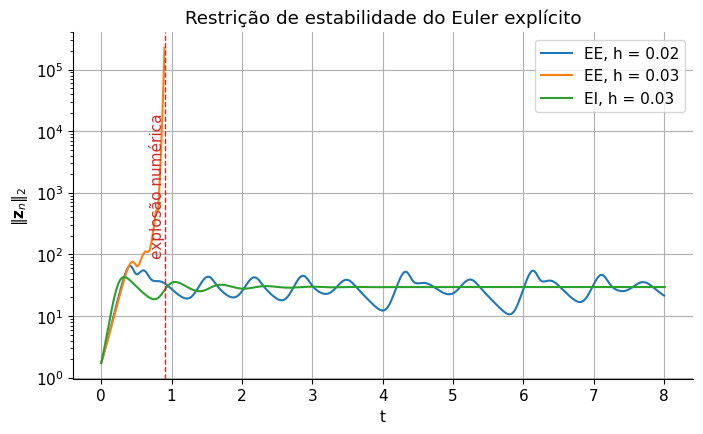

,método,explodiu?,tempo da explosão,Newton convergiu em todos os passos?,máx. iterações de Newton
0,"EE, h=0.02",False,NaN,NaN,NaN
1,"EE, h=0.03",True,0.9,NaN,NaN
2,"EI, h=0.03",False,NaN,True,4.0


In [7]:
t_stability_small = np.arange(0.0, 8.0 + 0.02 / 2.0, 0.02)
t_stability_large = np.arange(0.0, 8.0 + 0.03 / 2.0, 0.03)

ee_h002, blow_h002 = euler_explicito_lorenz(
    t_stability_small,
    z0_lorenz,
    lorenz_params,
    max_norm=1e5,
)
ee_h003, blow_h003 = euler_explicito_lorenz(
    t_stability_large,
    z0_lorenz,
    lorenz_params,
    max_norm=1e5,
)
ei_h003, ei_h003_iterations, ei_h003_converged = euler_implicito_lorenz(
    t_stability_large,
    z0_lorenz,
    lorenz_params,
)

fig, ax = plt.subplots()
ax.semilogy(t_stability_small, np.linalg.norm(ee_h002, axis=1), label="EE, h = 0.02")
ax.semilogy(t_stability_large, np.linalg.norm(ee_h003, axis=1), label="EE, h = 0.03")
ax.semilogy(t_stability_large, np.linalg.norm(ei_h003, axis=1), label="EI, h = 0.03")

if blow_h003 is not None:
    ax.axvline(
        t_stability_large[blow_h003], color="tab:red", linestyle="--", linewidth=1.0
    )
    ax.text(
        t_stability_large[blow_h003],
        2e4,
        "explosão numérica",
        rotation=90,
        va="top",
        ha="right",
        color="tab:red",
    )

ax.set_xlabel("t")
ax.set_ylabel(r"$\|\mathbf{z}_n\|_2$")
ax.set_title("Restrição de estabilidade do Euler explícito")
ax.legend()
plt.show()

pd.DataFrame(
    {
        "método": ["EE, h=0.02", "EE, h=0.03", "EI, h=0.03"],
        "explodiu?": [blow_h002 is not None, blow_h003 is not None, False],
        "tempo da explosão": [
            np.nan if blow_h002 is None else t_stability_small[blow_h002],
            np.nan if blow_h003 is None else t_stability_large[blow_h003],
            np.nan,
        ],
        "Newton convergiu em todos os passos?": [
            np.nan,
            np.nan,
            bool(np.all(ei_h003_converged)),
        ],
        "máx. iterações de Newton": [np.nan, np.nan, int(np.max(ei_h003_iterations))],
    }
)

O Euler explícito com $h=0.03$ perde estabilidade rapidamente, enquanto o Euler implícito permanece numericamente estável com o mesmo passo. Isso ilustra uma característica típica de problemas rígidos: métodos explícitos podem ser limitados por estabilidade.

Porém, estabilidade não é o mesmo que precisão. O Euler implícito é mais robusto, mas também introduz dissipação numérica forte, como veremos a seguir.

### Comparando Euler explícito e implícito com uma referência

Agora usamos o mesmo passo $h=0.02$ para Euler explícito e implícito, em um intervalo maior. A referência será a solução adaptativa com `Radau`, avaliada nos mesmos tempos.

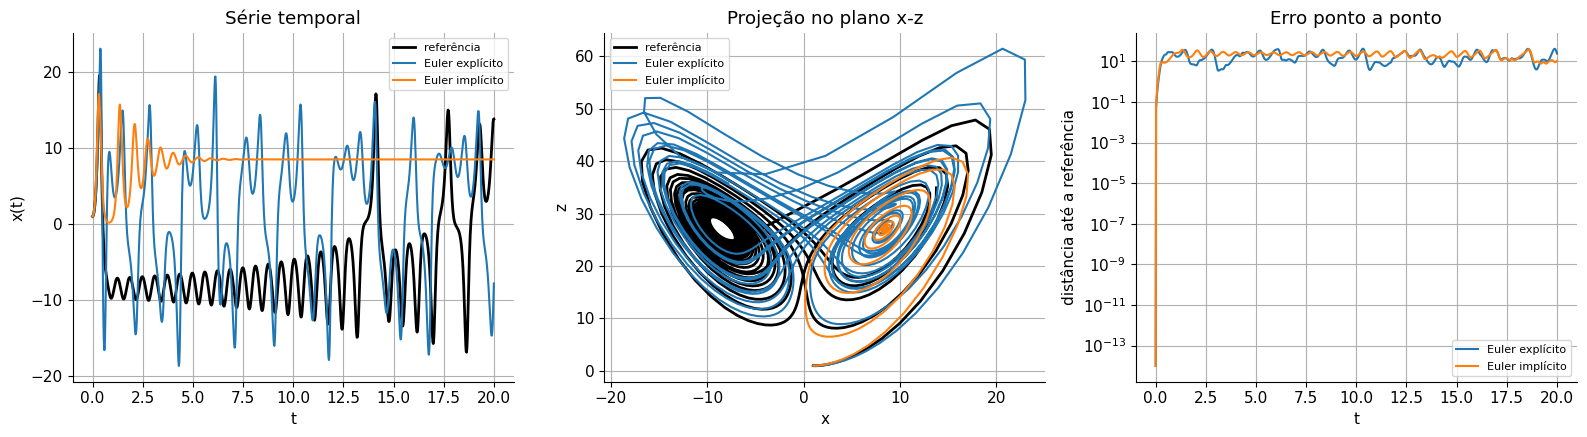

,método,h,explodiu?,distância final até referência,máx. iterações de Newton,Newton convergiu em todos os passos?
0,Euler explícito,0.02,False,24.149182,NaN,NaN
1,Euler implícito,0.02,False,10.514764,4.0,True


In [8]:
h_manual = 0.02
t_manual = np.arange(0.0, 20.0 + h_manual / 2.0, h_manual)

manual_reference = sol_reference.sol(t_manual).T

manual_explicit, manual_explicit_blow = euler_explicito_lorenz(
    t_manual,
    z0_lorenz,
    lorenz_params,
    max_norm=1e8,
)
manual_implicit, manual_implicit_iterations, manual_implicit_converged = (
    euler_implicito_lorenz(
        t_manual,
        z0_lorenz,
        lorenz_params,
    )
)

manual_explicit_error = np.linalg.norm(manual_explicit - manual_reference, axis=1)
manual_implicit_error = np.linalg.norm(manual_implicit - manual_reference, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(
    t_manual, manual_reference[:, 0], color="black", linewidth=2.0, label="referência"
)
axes[0].plot(t_manual, manual_explicit[:, 0], label="Euler explícito")
axes[0].plot(t_manual, manual_implicit[:, 0], label="Euler implícito")
axes[0].set_xlabel("t")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Série temporal")
axes[0].legend(fontsize=8)

axes[1].plot(
    manual_reference[:, 0],
    manual_reference[:, 2],
    color="black",
    linewidth=2.0,
    label="referência",
)
axes[1].plot(manual_explicit[:, 0], manual_explicit[:, 2], label="Euler explícito")
axes[1].plot(manual_implicit[:, 0], manual_implicit[:, 2], label="Euler implícito")
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
axes[1].set_title("Projeção no plano x-z")
axes[1].legend(fontsize=8)

axes[2].semilogy(
    t_manual, np.maximum(manual_explicit_error, 1e-14), label="Euler explícito"
)
axes[2].semilogy(
    t_manual, np.maximum(manual_implicit_error, 1e-14), label="Euler implícito"
)
axes[2].set_xlabel("t")
axes[2].set_ylabel("distância até a referência")
axes[2].set_title("Erro ponto a ponto")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "método": ["Euler explícito", "Euler implícito"],
        "h": [h_manual, h_manual],
        "explodiu?": [manual_explicit_blow is not None, False],
        "distância final até referência": [
            manual_explicit_error[-1],
            manual_implicit_error[-1],
        ],
        "máx. iterações de Newton": [np.nan, int(np.max(manual_implicit_iterations))],
        "Newton convergiu em todos os passos?": [
            np.nan,
            bool(np.all(manual_implicit_converged)),
        ],
    }
)

O Euler implícito se mantém estável, mas a solução é fortemente amortecida: ela tende artificialmente para um dos equilíbrios não triviais do sistema. Isso é dissipação numérica. O Euler explícito, por outro lado, pode preservar melhor a aparência oscilatória por algum tempo, mas é muito sensível ao passo e perde confiabilidade rapidamente.

A mensagem importante é: em um sistema rígido ou quase rígido, estabilidade é necessária, mas não é suficiente. Um método estável pode ainda distorcer a dinâmica qualitativa.

## Comparando métodos adaptativos da `scipy`

Agora comparamos métodos prontos de `solve_ivp`:

* `RK45`: Runge-Kutta explícito adaptativo;
* `DOP853`: Runge-Kutta explícito de alta ordem;
* `Radau`: Runge-Kutta implícito, adequado para problemas rígidos;
* `BDF`: fórmulas de diferenciação regressiva, também adequadas para problemas rígidos;
* `LSODA`: alterna automaticamente entre métodos do tipo Adams e BDF.

Usaremos tolerâncias iguais para todos e compararemos custo, erro em tempo curto e separação em tempo longo. Como a referência foi calculada com `Radau`, a comparação de erro favorece parcialmente esse método; isso é intencional aqui, pois a referência foi escolhida justamente como uma solução implícita robusta para discutir rigidez.

In [9]:
scipy_methods_lorenz = ["RK45", "DOP853", "Radau", "BDF", "LSODA"]


def time_to_threshold(distance, t, threshold):
    indices = np.flatnonzero(distance > threshold)
    if len(indices) == 0:
        return np.nan
    return t[indices[0]]


lorenz_scipy_rows = []
lorenz_scipy_solutions = {}

for method in scipy_methods_lorenz:
    tic = perf_counter()
    solution = sp.integrate.solve_ivp(
        lorenz_rhs,
        t_span=(0.0, T_lorenz),
        y0=z0_lorenz,
        args=lorenz_params,
        method=method,
        t_eval=t_eval_lorenz,
        rtol=1e-7,
        atol=1e-9,
    )
    elapsed_ms = 1e3 * (perf_counter() - tic)

    trajectory = solution.y.T
    distance_to_reference = np.linalg.norm(trajectory - lorenz_reference, axis=1)
    short_mask = solution.t <= 10.0

    lorenz_scipy_solutions[method] = {
        "solution": solution,
        "trajectory": trajectory,
        "distance": distance_to_reference,
    }
    lorenz_scipy_rows.append(
        {
            "método": method,
            "sucesso": solution.success,
            "nfev": solution.nfev,
            "njev": getattr(solution, "njev", 0),
            "nlu": getattr(solution, "nlu", 0),
            "tempo (ms)": elapsed_ms,
            "erro máx. até t=10": np.max(distance_to_reference[short_mask]),
            "tempo até distância > 1": time_to_threshold(
                distance_to_reference, solution.t, threshold=1.0
            ),
            "distância final": distance_to_reference[-1],
        }
    )

comparison_lorenz_scipy = pd.DataFrame(lorenz_scipy_rows)
comparison_lorenz_scipy

,método,sucesso,nfev,njev,nlu,tempo (ms),erro máx. até t=10,tempo até distância > 1,distância final
0,RK45,True,14642,0,0,459.456712,0.000302,18.49,13.120468
1,DOP853,True,12449,0,0,289.108923,0.000039,21.39,31.869640
2,Radau,True,49403,235,1412,3342.508571,0.000001,25.22,9.591305
3,BDF,True,16385,24,1127,2013.513295,0.000382,18.59,13.890401
4,LSODA,True,8839,27,27,229.690979,0.000296,18.48,10.345624


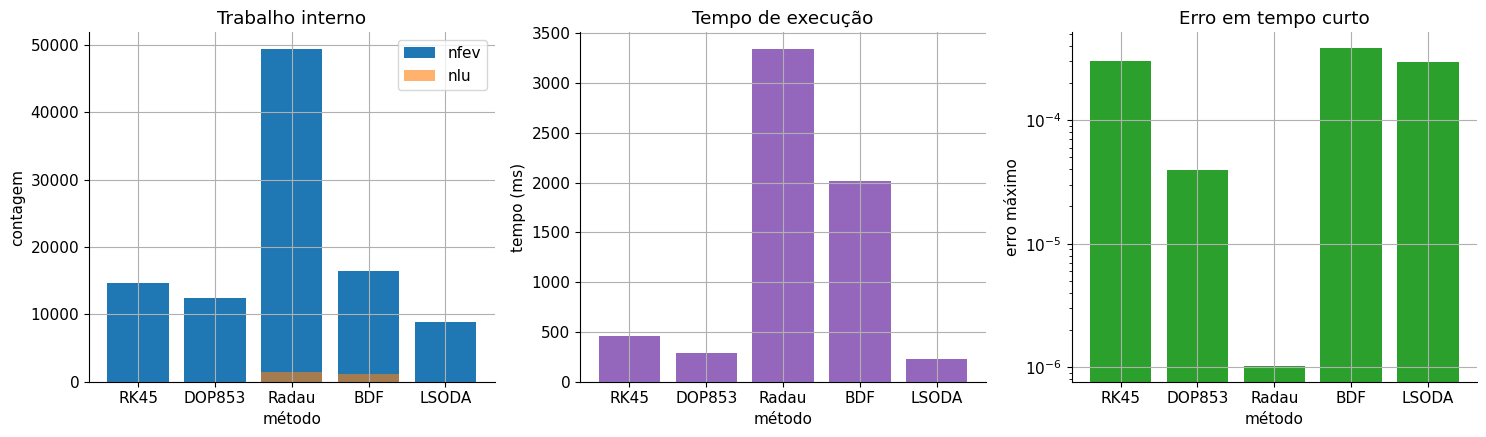

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
methods = comparison_lorenz_scipy["método"]
positions = np.arange(len(methods))

axes[0].bar(positions, comparison_lorenz_scipy["nfev"], label="nfev")
axes[0].bar(positions, comparison_lorenz_scipy["nlu"], bottom=0, alpha=0.6, label="nlu")
axes[0].set_xticks(positions)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel("contagem")
axes[0].set_title("Trabalho interno")
axes[0].legend()

axes[1].bar(methods, comparison_lorenz_scipy["tempo (ms)"], color="tab:purple")
axes[1].set_ylabel("tempo (ms)")
axes[1].set_title("Tempo de execução")

axes[2].bar(methods, comparison_lorenz_scipy["erro máx. até t=10"], color="tab:green")
axes[2].set_yscale("log")
axes[2].set_ylabel("erro máximo")
axes[2].set_title("Erro em tempo curto")

for ax in axes:
    ax.set_xlabel("método")

fig.tight_layout()
plt.show()

Métodos implícitos (`Radau` e `BDF`) têm custo adicional porque precisam resolver sistemas algébricos internos, o que aparece em `njev` e `nlu`. Eles são essenciais em muitos problemas rígidos, mas não são automaticamente mais rápidos para qualquer sistema difícil.

No Lorenz clássico, a dificuldade dominante em tempos longos é a sensibilidade caótica. Por isso, o erro em tempo curto é a métrica mais honesta para avaliar precisão ponto a ponto. Em tempos longos, a distância até uma referência cresce e satura, mesmo quando o método preserva a geometria qualitativa do atrator.

## Tempos longos: soluções diferentes não significam necessariamente soluções erradas

Vamos comparar as trajetórias obtidas pelos métodos em relação à referência. A pergunta aqui não é “qual curva coincide para sempre?”, porque isso não é esperado em um sistema caótico. A pergunta é: por quanto tempo as trajetórias permanecem próximas e que comportamento qualitativo preservam depois disso?

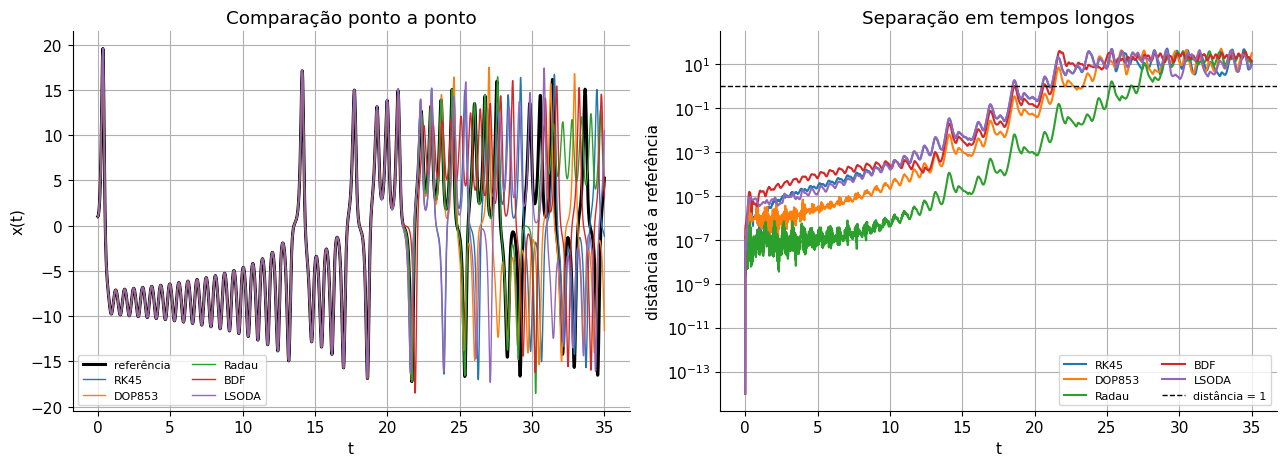

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    sol_reference.t,
    lorenz_reference[:, 0],
    color="black",
    linewidth=2.2,
    label="referência",
)
for method, data in lorenz_scipy_solutions.items():
    axes[0].plot(
        data["solution"].t, data["trajectory"][:, 0], linewidth=1.0, label=method
    )

axes[0].set_xlabel("t")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Comparação ponto a ponto")
axes[0].legend(ncol=2, fontsize=8)

for method, data in lorenz_scipy_solutions.items():
    axes[1].semilogy(
        data["solution"].t, np.maximum(data["distance"], 1e-14), label=method
    )

axes[1].axhline(
    1.0, color="black", linestyle="--", linewidth=1.0, label="distância = 1"
)
axes[1].set_xlabel("t")
axes[1].set_ylabel("distância até a referência")
axes[1].set_title("Separação em tempos longos")
axes[1].legend(ncol=2, fontsize=8)

fig.tight_layout()
plt.show()

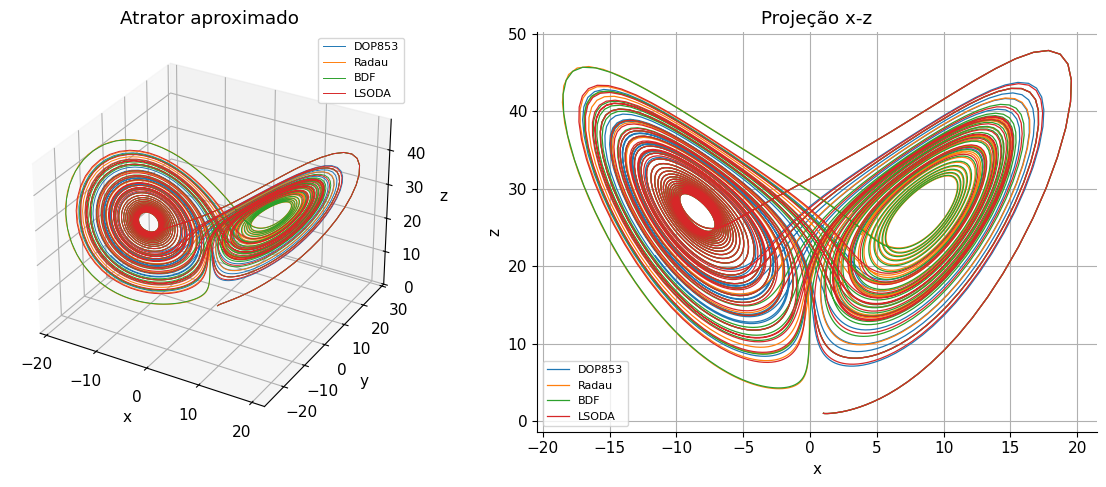

In [12]:
fig = plt.figure(figsize=(12, 5))
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
ax_xz = fig.add_subplot(1, 2, 2)

selected_methods = ["DOP853", "Radau", "BDF", "LSODA"]
for method in selected_methods:
    trajectory = lorenz_scipy_solutions[method]["trajectory"]
    ax_3d.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        trajectory[:, 2],
        linewidth=0.7,
        label=method,
    )
    ax_xz.plot(trajectory[:, 0], trajectory[:, 2], linewidth=0.9, label=method)

ax_3d.set_xlabel("x")
ax_3d.set_ylabel("y")
ax_3d.set_zlabel("z")
ax_3d.set_title("Atrator aproximado")
ax_3d.legend(fontsize=8)

ax_xz.set_xlabel("x")
ax_xz.set_ylabel("z")
ax_xz.set_title("Projeção x-z")
ax_xz.legend(fontsize=8)

fig.tight_layout()
plt.show()

No gráfico de distância, as curvas se afastam da referência após certo tempo. Isso é esperado: pequenas diferenças de truncamento, arredondamento e controle adaptativo de passo são amplificadas pela dinâmica caótica.

Em aplicações desse tipo, exigir coincidência ponto a ponto para tempos longos pode ser uma métrica inadequada. É mais informativo avaliar propriedades qualitativas e estatísticas: geometria do atrator, intervalos típicos das variáveis, médias temporais, frequências de visita às regiões do espaço de fases etc.

## Uma perturbação minúscula na condição inicial

Para separar o efeito de “método numérico” do efeito de sensibilidade dinâmica, vamos resolver o mesmo problema duas vezes com o mesmo método, mas perturbando a condição inicial em apenas $10^{-8}$ na primeira componente.

Aqui vamos usar `LSODA` e uma janela temporal maior que nas comparações anteriores. O objetivo é deixar mais visível que duas trajetórias praticamente indistinguíveis no início podem se separar completamente em tempos longos.

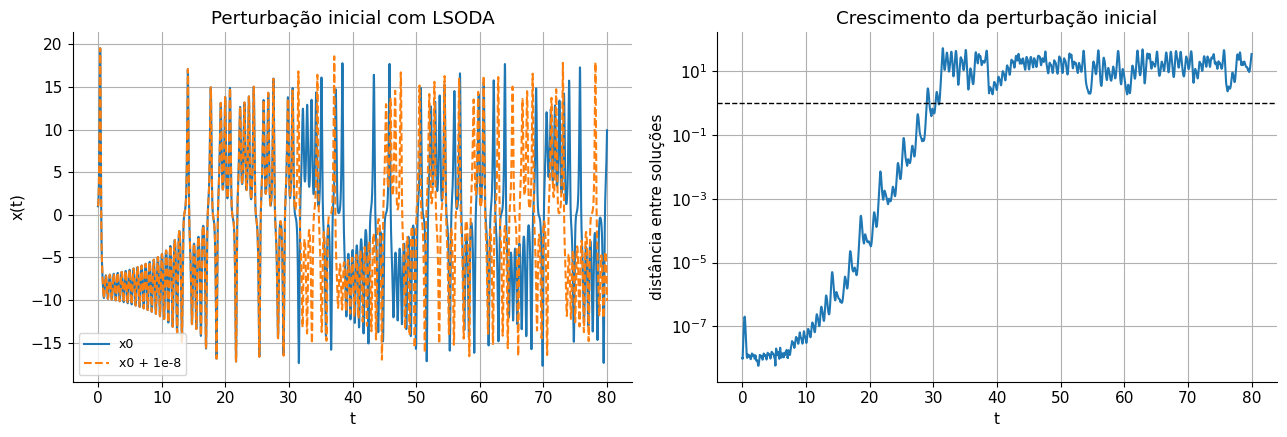

In [13]:
T_perturbation = 80.0
t_eval_perturbation = np.linspace(0.0, T_perturbation, 8001)

z0_lorenz_perturbed = z0_lorenz.copy()
z0_lorenz_perturbed[0] += 1e-8

sol_initial = sp.integrate.solve_ivp(
    lorenz_rhs,
    t_span=(0.0, T_perturbation),
    y0=z0_lorenz,
    args=lorenz_params,
    method="LSODA",
    t_eval=t_eval_perturbation,
    rtol=1e-10,
    atol=1e-12,
)
sol_initial_perturbed = sp.integrate.solve_ivp(
    lorenz_rhs,
    t_span=(0.0, T_perturbation),
    y0=z0_lorenz_perturbed,
    args=lorenz_params,
    method="LSODA",
    t_eval=t_eval_perturbation,
    rtol=1e-10,
    atol=1e-12,
)

distance_perturbed_initial = np.linalg.norm(
    sol_initial.y.T - sol_initial_perturbed.y.T, axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sol_initial.t, sol_initial.y[0], label="x0")
axes[0].plot(
    sol_initial_perturbed.t, sol_initial_perturbed.y[0], "--", label="x0 + 1e-8"
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Perturbação inicial com LSODA")
axes[0].legend(fontsize=9)

axes[1].semilogy(sol_initial.t, np.maximum(distance_perturbed_initial, 1e-16))
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("t")
axes[1].set_ylabel("distância entre soluções")
axes[1].set_title("Crescimento da perturbação inicial")

fig.tight_layout()
plt.show()

Esse experimento mostra por que, no Lorenz, soluções de longo prazo podem diferir mesmo quando usamos métodos de alta qualidade. A diferença não vem apenas da rigidez ou da escolha do solver; ela também é uma propriedade do próprio sistema dinâmico.

Portanto, há duas mensagens complementares:

* para lidar com rigidez, métodos implícitos e controle adaptativo de passo são ferramentas importantes;
* para sistemas caóticos, a comparação em tempos longos deve ser feita com cuidado, pois a concordância ponto a ponto inevitavelmente se perde.